# 02 — Línea base clásica: SVM-RBF

Este notebook es el **registro de ejecución** de las Partes 1 y 2 del enunciado (preparación de
datos y línea base clásica). No duplica lógica: llama directamente a las funciones de
`src/data_prep/prepare_data.py` y `src/classical/baseline.py`, que son la fuente de verdad
reproducible. Ejecutar este notebook de principio a fin regenera:

- `data/processed/` (train/test imputado, estandarizado y balanceado)
- `data/quantum_subset/` (subconjuntos de 16/32/64 muestras para la Parte 3)
- `results/metrics/classical_baseline.json`
- `results/figures/fig_confusion_matrix_classical.png`

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.data_prep import prepare_data
from src.classical import baseline

## Paso 1 — Preparación de datos (Parte 1)

Orden a prueba de fuga de datos: split estratificado 80/20 primero, luego imputación por
mediana por clase (mediana calculada solo con train), estandarización (fit solo con train),
balanceo por submuestreo (solo en train), y selección de subconjuntos balanceados de
16/32/64 muestras **desde el train balanceado**, nunca desde test.

`prepare_data.main()` ejecuta todo el pipeline y escribe los artefactos en
`data/processed/` y `data/quantum_subset/`.

In [2]:
prepare_data.main()

Train (balanced): (2044, 9) | Test: (656, 9)
Train class counts (balanced): {0: 1022, 1: 1022}
Test class counts: {0: 400, 1: 256}
Quantum subsets written for sizes: (16, 32, 64)


In [3]:
import json

with open(prepare_data.PROCESSED_DIR / "metadata.json") as f:
    processed_metadata = json.load(f)
processed_metadata

{'seed': 42,
 'test_size': 0.2,
 'balance_method': 'undersample',
 'train_size_before_balance': 2620,
 'train_size_after_balance': 2044,
 'test_size_n': 656,
 'class_counts_train_before_balance': {'0': 1598, '1': 1022},
 'class_counts_train_after_balance': {'0': 1022, '1': 1022},
 'class_counts_test': {'0': 400, '1': 256},
 'imputation_medians_by_class': {'0': {'ph': 7.013539744397472,
   'Hardness': 196.5954140214223,
   'Solids': 20717.10506073064,
   'Chloramines': 7.103510578912478,
   'Sulfate': 333.1483176590248,
   'Conductivity': 424.47130181708735,
   'Organic_carbon': 14.215790896505126,
   'Trihalomethanes': 66.28481945089318,
   'Turbidity': 3.975469385069254},
  '1': {'ph': 7.063646975622253,
   'Hardness': 197.54220207030636,
   'Solids': 21150.782365789513,
   'Chloramines': 7.1449952666023595,
   'Sulfate': 332.9363746084408,
   'Conductivity': 425.51786735389294,
   'Organic_carbon': 14.202889133733294,
   'Trihalomethanes': 66.68609327475363,
   'Turbidity': 3.9661262

## Paso 2 — Línea base SVM-RBF (Parte 2)

`baseline.train_and_evaluate` ejecuta `GridSearchCV` sobre la grilla completa
`C ∈ {0.1, 1, 10} × gamma ∈ {scale, auto, 0.01}` (9 combinaciones), cada una evaluada con
**CV de 5 particiones** → 9 × 5 = **45 entrenamientos de SVM** durante la búsqueda, más
**1 reentrenamiento final** sobre todo el train balanceado con los mejores hiperparámetros
(`refit=True` por defecto en `GridSearchCV`) → **46 SVM entrenadas en total**. Solo ese modelo
final se evalúa, una vez, sobre el test set reservado.

In [4]:
X_train, X_test, y_train, y_test = baseline.load_processed()
best_model, metrics = baseline.train_and_evaluate(X_train, y_train, X_test, y_test)
metrics

{'best_params': {'C': 10, 'gamma': 'auto'},
 'cv_best_f1': 0.6263236127106935,
 'accuracy': 0.600609756097561,
 'precision': 0.48863636363636365,
 'recall': 0.50390625,
 'f1': 0.49615384615384617,
 'confusion_matrix': [[265, 135], [127, 129]]}

## Guardar métricas y matriz de confusión

Reutiliza `baseline.plot_confusion_matrix`, la misma función que usa el punto de entrada por
terminal, para que la figura sea idéntica sin importar cómo se ejecute el pipeline.

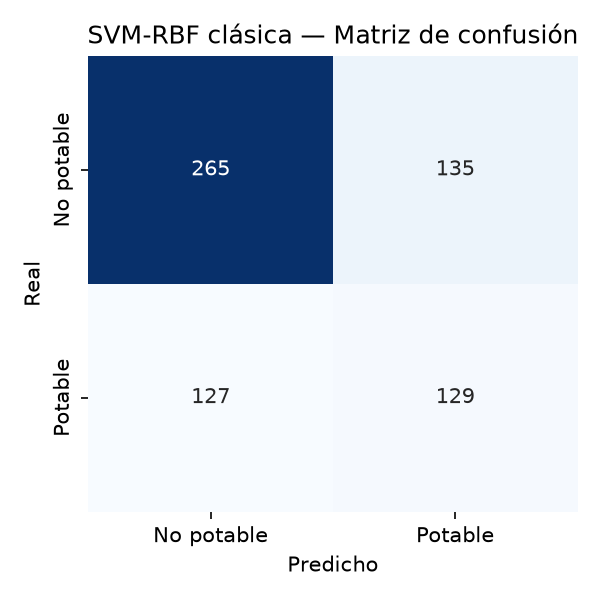

In [5]:
baseline.METRICS_DIR.mkdir(parents=True, exist_ok=True)
baseline.FIGURES_DIR.mkdir(parents=True, exist_ok=True)

with open(baseline.METRICS_DIR / "classical_baseline.json", "w") as f:
    json.dump(metrics, f, indent=2)

cm_path = baseline.FIGURES_DIR / "fig_confusion_matrix_classical.png"
baseline.plot_confusion_matrix(metrics["confusion_matrix"], cm_path)

from IPython.display import Image, display
display(Image(filename=str(cm_path)))

## Interpretación

- Mejores hiperparámetros y F1 promedio de CV vs. F1 en el test set reservado (compararlos:
  si el de CV es notablemente más alto que el de test, hay señal de sobreajuste a los folds).
- Estas cinco métricas (exactitud, precisión, recall, F1, matriz de confusión) son la referencia
  fija contra la que se compara la QSVM en `03_quantum_kernel.ipynb` y `04_feature_map_study.ipynb`
  — mismo test set, mismas definiciones de métrica, para que la comparación sea justa.

In [6]:
print(f"CV best F1 (5-fold, grid search): {metrics['cv_best_f1']:.3f}")
print(f"Test accuracy:  {metrics['accuracy']:.3f}")
print(f"Test precision: {metrics['precision']:.3f}")
print(f"Test recall:    {metrics['recall']:.3f}")
print(f"Test F1:        {metrics['f1']:.3f}")
print(f"Best params:    {metrics['best_params']}")

CV best F1 (5-fold, grid search): 0.626
Test accuracy:  0.601
Test precision: 0.489
Test recall:    0.504
Test F1:        0.496
Best params:    {'C': 10, 'gamma': 'auto'}
